In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import json, os
import joblib
from itertools import product
from scipy.signal import butter, filtfilt

import matplotlib.ticker as mticker
import pandas as pd
import control as ctl

In [2]:
OPTIONS = json.loads(open('info.json', 'r').read())
OPTIONS

{'dt': 0.045,
 'offset': 3,
 'view_range': [0.7, 0.8],
 'sensor_range': [400, 900],
 'actuator_range': [0, 255],
 'sensor_filter': {'num': [0.3612210092368324, 0.36122100923683254],
  'den': [1.0, -0.27755798152633504]},
 'Fc': 4.0,
 'ts': 0.432}

In [3]:
df   = pd.read_csv('../Dataset/data_cleaned.csv')
K_CV = 5
TEMPORAL = True

X_MIN, X_MAX = OPTIONS.get('view_range')
dt = OPTIONS.get('dt')
ts = OPTIONS.get('ts')
OFFSET = OPTIONS.get('offset')
df

,time,input,sensor
0,0.000,255,364.110777
1,0.045,255,717.666115
2,0.090,255,630.491843
3,0.135,255,524.298759
4,0.180,255,470.983435
...,...,...,...
2172,97.740,122,475.655785
2173,97.785,122,489.630859
2174,97.830,122,478.338470
2175,97.875,122,466.896094


Text(0, 0.5, 'sensor')

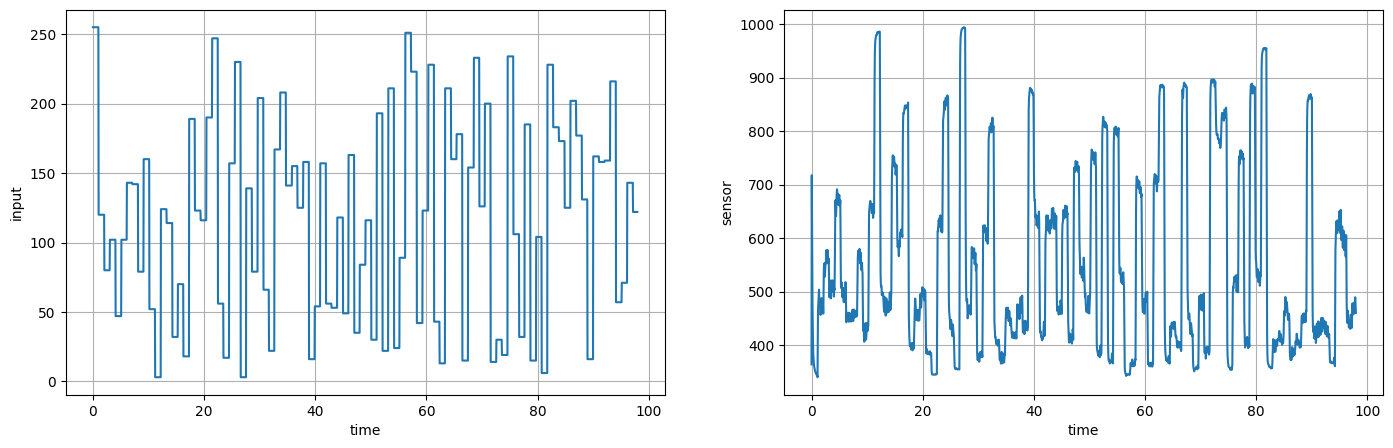

In [4]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(df.time, df.input)
plt.grid()
plt.xlabel('time'); plt.ylabel('input')

plt.subplot(1, 2, 2)
plt.plot(df.time, df.sensor)
plt.grid()
plt.xlabel('time'); plt.ylabel('sensor')

In [5]:
def getStates(df, key, var='y', n=10, last=True):
    table = df.copy() 
    table[f'{var}'] = table[key]

    for i in range(1, n):
        table[f'{var}(n-{i})'] = table[key].shift(i)

    table.fillna(0, inplace=True)
    columns = [f'{var}'] + [f'{var}(n-{i})' for i in range(1, n)]

    if not last:
        columns = columns[1:]

    return table[columns]


N_STATES = OFFSET + 5
xData    = pd.concat([
    getStates(df, 'input',  var='u', n=N_STATES, last=True), 
    getStates(df, 'sensor', var='x', n=N_STATES, last=False)
], axis=1)

xData = xData.iloc[N_STATES:].reset_index(drop=True)
yData = df.sensor.values[N_STATES:]
xData

,u,u(n-1),u(n-2),u(n-3),u(n-4),u(n-5),u(n-6),u(n-7),x(n-1),x(n-2),x(n-3),x(n-4),x(n-5),x(n-6),x(n-7)
0,255,255.0,255.0,255.0,255.0,255.0,255.0,255.0,384.316070,403.358710,431.622312,470.983435,524.298759,630.491843,717.666115
1,255,255.0,255.0,255.0,255.0,255.0,255.0,255.0,373.973540,384.316070,403.358710,431.622312,470.983435,524.298759,630.491843
2,255,255.0,255.0,255.0,255.0,255.0,255.0,255.0,367.129457,373.973540,384.316070,403.358710,431.622312,470.983435,524.298759
3,255,255.0,255.0,255.0,255.0,255.0,255.0,255.0,362.340059,367.129457,373.973540,384.316070,403.358710,431.622312,470.983435
4,255,255.0,255.0,255.0,255.0,255.0,255.0,255.0,359.204618,362.340059,367.129457,373.973540,384.316070,403.358710,431.622312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2164,122,122.0,122.0,122.0,122.0,122.0,122.0,122.0,460.444165,466.805961,474.109457,479.600060,469.449098,457.603779,459.175327
2165,122,122.0,122.0,122.0,122.0,122.0,122.0,122.0,475.655785,460.444165,466.805961,474.109457,479.600060,469.449098,457.603779
2166,122,122.0,122.0,122.0,122.0,122.0,122.0,122.0,489.630859,475.655785,460.444165,466.805961,474.109457,479.600060,469.449098
2167,122,122.0,122.0,122.0,122.0,122.0,122.0,122.0,478.338470,489.630859,475.655785,460.444165,466.805961,474.109457,479.600060


In [6]:
from Selector.index import ModelSelector

In [7]:
selector = ModelSelector('linear_regression')
model, params = selector.get()
model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [8]:
from GridSearch.index import GridSearch

In [9]:
grid = GridSearch(model, params, xData, yData, K_CV, temporal=TEMPORAL)
grid.update()

model, r2_adj = grid.evaluate()
print('best_R2_Adjusted:', r2_adj)
model

Fitting 5 folds for each of 4 candidates, totalling 20 fits
best_R2_Adjusted: 0.9937533996349488


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [10]:
from Metrics.CrossValidation.index import CrossValidation
from Metrics.GaussianAnalyser.index import GaussianAnalyser

In [11]:
cross = CrossValidation(model, xData, yData, K_CV, temporal=TEMPORAL)
cross.update()

if not TEMPORAL:
    analyser = GaussianAnalyser(cross)
    analyser.update()
    analyser.plot()
    analyser.info()

In [12]:
from Metrics.Plotter.index import Plotter

In [13]:
cross.print()

R2: 0.9932 (±0.0026) [Erro Absoluto]
R2_ADJ: 0.9929 (±0.0027) [Erro Absoluto]
RMSE: 13.8389 (±3.9637) [Erro Absoluto]
MAE: 7.3741 (±0.9809) [Erro Absoluto]


,name,values,mean,std,min,max,split_1,split_2,split_3,split_4,split_5
0,R2,"[0.9883581899004573, 0.9952568436993702, 0.994...",0.993198,0.002564,0.988358,0.995290,0.988358,0.995257,0.994090,0.995290,0.992994
1,R2_ADJ,"[0.9878520242439555, 0.9950506195123863, 0.993...",0.992902,0.002676,0.987852,0.995085,0.987852,0.995051,0.993833,0.995085,0.992690
2,RMSE,"[20.75196867766866, 9.268829906063305, 13.9205...",13.838944,3.963749,9.268830,20.751969,20.751969,9.268830,13.920566,14.488776,10.764579
3,MAE,"[8.81445709388415, 6.1855415805744745, 7.69183...",7.374144,0.980891,6.185542,8.814457,8.814457,6.185542,7.691836,7.817597,6.361287


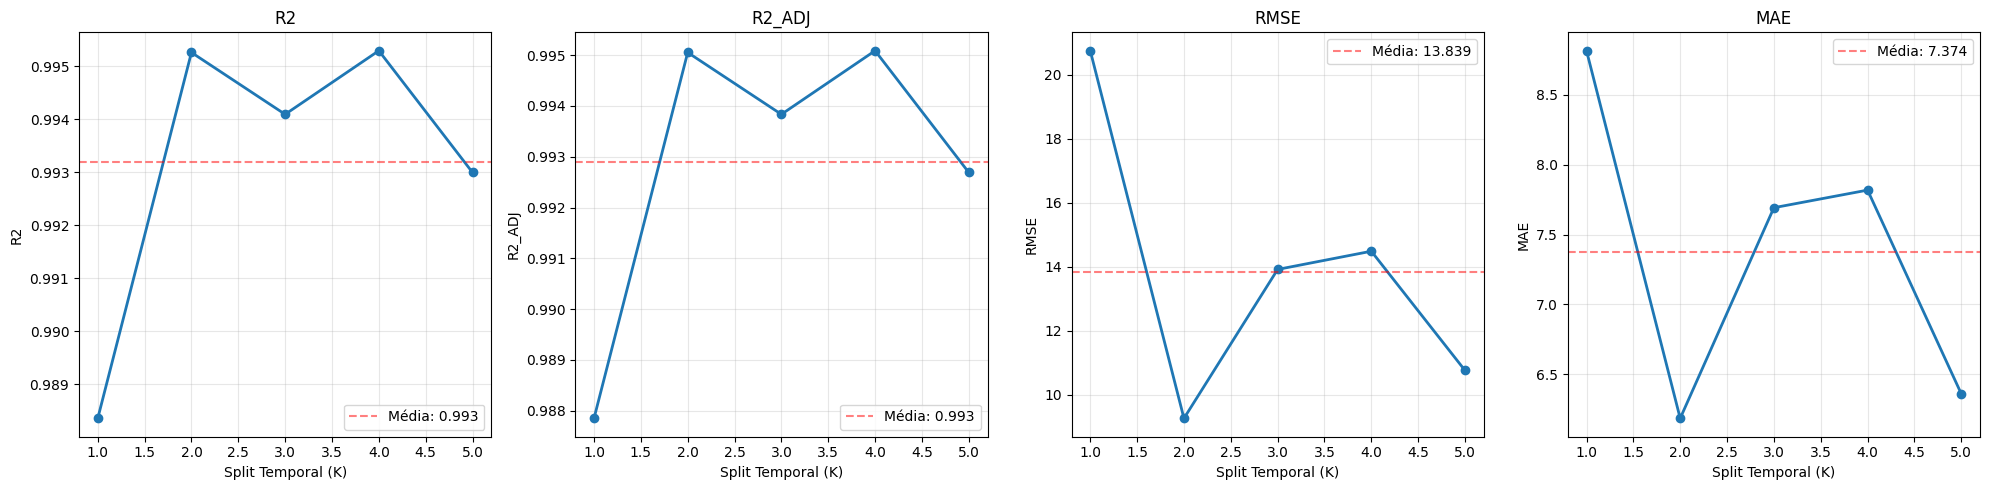

In [14]:
cross.plot()

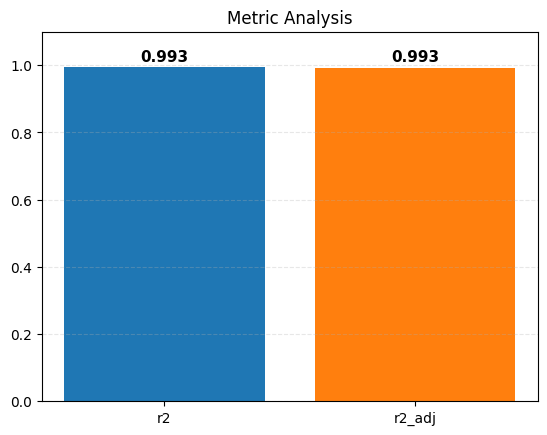

In [15]:
info = {'r2': cross.r2, 'r2_adj': cross.adj_r2}
Plotter(info)

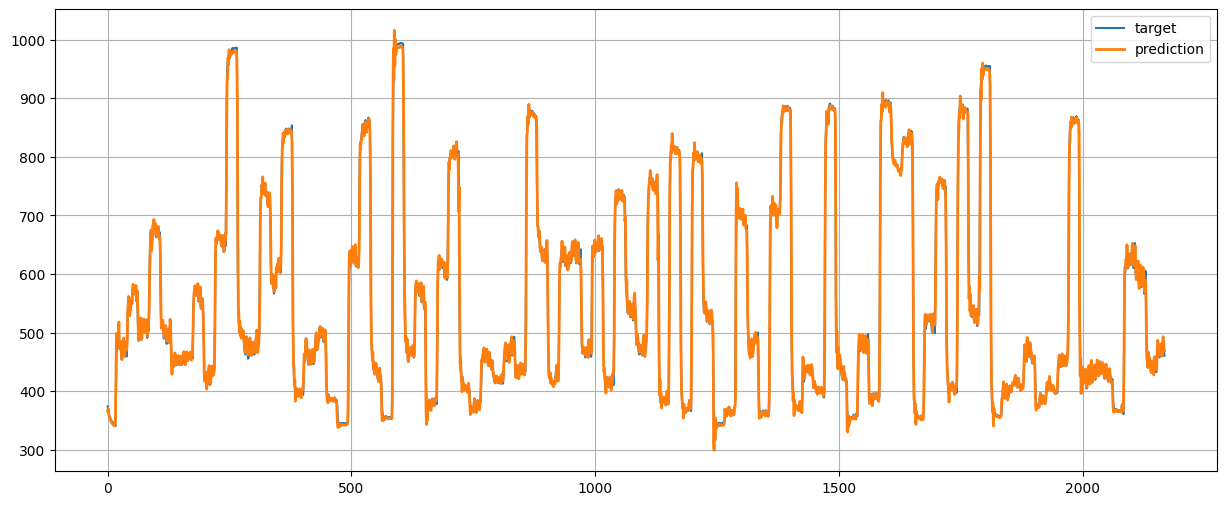

In [16]:
plt.figure(figsize=(15, 6))
plt.plot(yData, label='target')
plt.plot(model.predict(xData), label='prediction', linewidth=2)
plt.grid(); plt.legend()
plt.show()

In [17]:
model.fit(xData, yData)
model.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('model', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'model': LinearRegression(),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'model__copy_X': True,
 'model__fit_intercept': True,
 'model__n_jobs': None,
 'model__positive': False,
 'model__tol': 1e-06}

In [18]:
model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [19]:
results = {
    'model': selector.chosen,
    'params': {key: str(value) for key, value in model.get_params().items()},
    'K_CV': K_CV,
    'info': analyser.info() if not TEMPORAL else cross.info(),
    'variables': xData.columns.tolist()
}

display(pd.DataFrame([results.get('info')]))
results

,r2,r2_adj,rmse,mae
0,0.993198,0.992902,13.838944,7.374144


{'model': 'linear_regression',
 'params': {'memory': 'None',
  'steps': "[('scaler', StandardScaler()), ('model', LinearRegression())]",
  'transform_input': 'None',
  'verbose': 'False',
  'scaler': 'StandardScaler()',
  'model': 'LinearRegression()',
  'scaler__copy': 'True',
  'scaler__with_mean': 'True',
  'scaler__with_std': 'True',
  'model__copy_X': 'True',
  'model__fit_intercept': 'True',
  'model__n_jobs': 'None',
  'model__positive': 'False',
  'model__tol': '1e-06'},
 'K_CV': 5,
 'info': {'r2': 0.9931979452377758,
  'r2_adj': 0.9929022037263747,
  'rmse': 13.838944063508283,
  'mae': 7.3741439123598935},
 'variables': ['u',
  'u(n-1)',
  'u(n-2)',
  'u(n-3)',
  'u(n-4)',
  'u(n-5)',
  'u(n-6)',
  'u(n-7)',
  'x(n-1)',
  'x(n-2)',
  'x(n-3)',
  'x(n-4)',
  'x(n-5)',
  'x(n-6)',
  'x(n-7)']}

In [20]:
os.makedirs('Backup/System', exist_ok=True)
index  = len(os.listdir('Backup/System')) + 1

output = f'Backup/System/model_{index}'
os.makedirs(output, exist_ok=True)

pd.Series(results).to_json(os.path.join(output, 'info.json'), indent=4)
joblib.dump(model, os.path.join(output, 'model.pkl'))

['Backup/System/model_1/model.pkl']